In [ ]:
# Load peristim matrix
from pathlib import Path
import numpy as np
%matplotlib inline
import spikeinterface as si
import matplotlib.pyplot as plt

import RCP_analysis as rcp

# Paths
REPO_ROOT = Path().resolve().parents[0]
PARAMS = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
TARGET = 'Target_B'
FILES = 'peristim__NRR_RW011_251203_154933__BR_024_target_B.npz'

npz_path = PERI_ROOT / TARGET / FILES

peristim_npz = np.load(npz_path, allow_pickle=True)

In [ ]:
NPRW_rel_t = peristim_npz['NPRW_rel_t']
NPRW_peak_ms_dedup = peristim_npz['NPRW_peak_ms_dedup']
NPRW_counts = peristim_npz['NPRW_counts']
NPRW_rates_zeroed = peristim_npz['NPRW_rates_zeroed']
# peristim_npz['stim_ms']

(19, 128, 106)

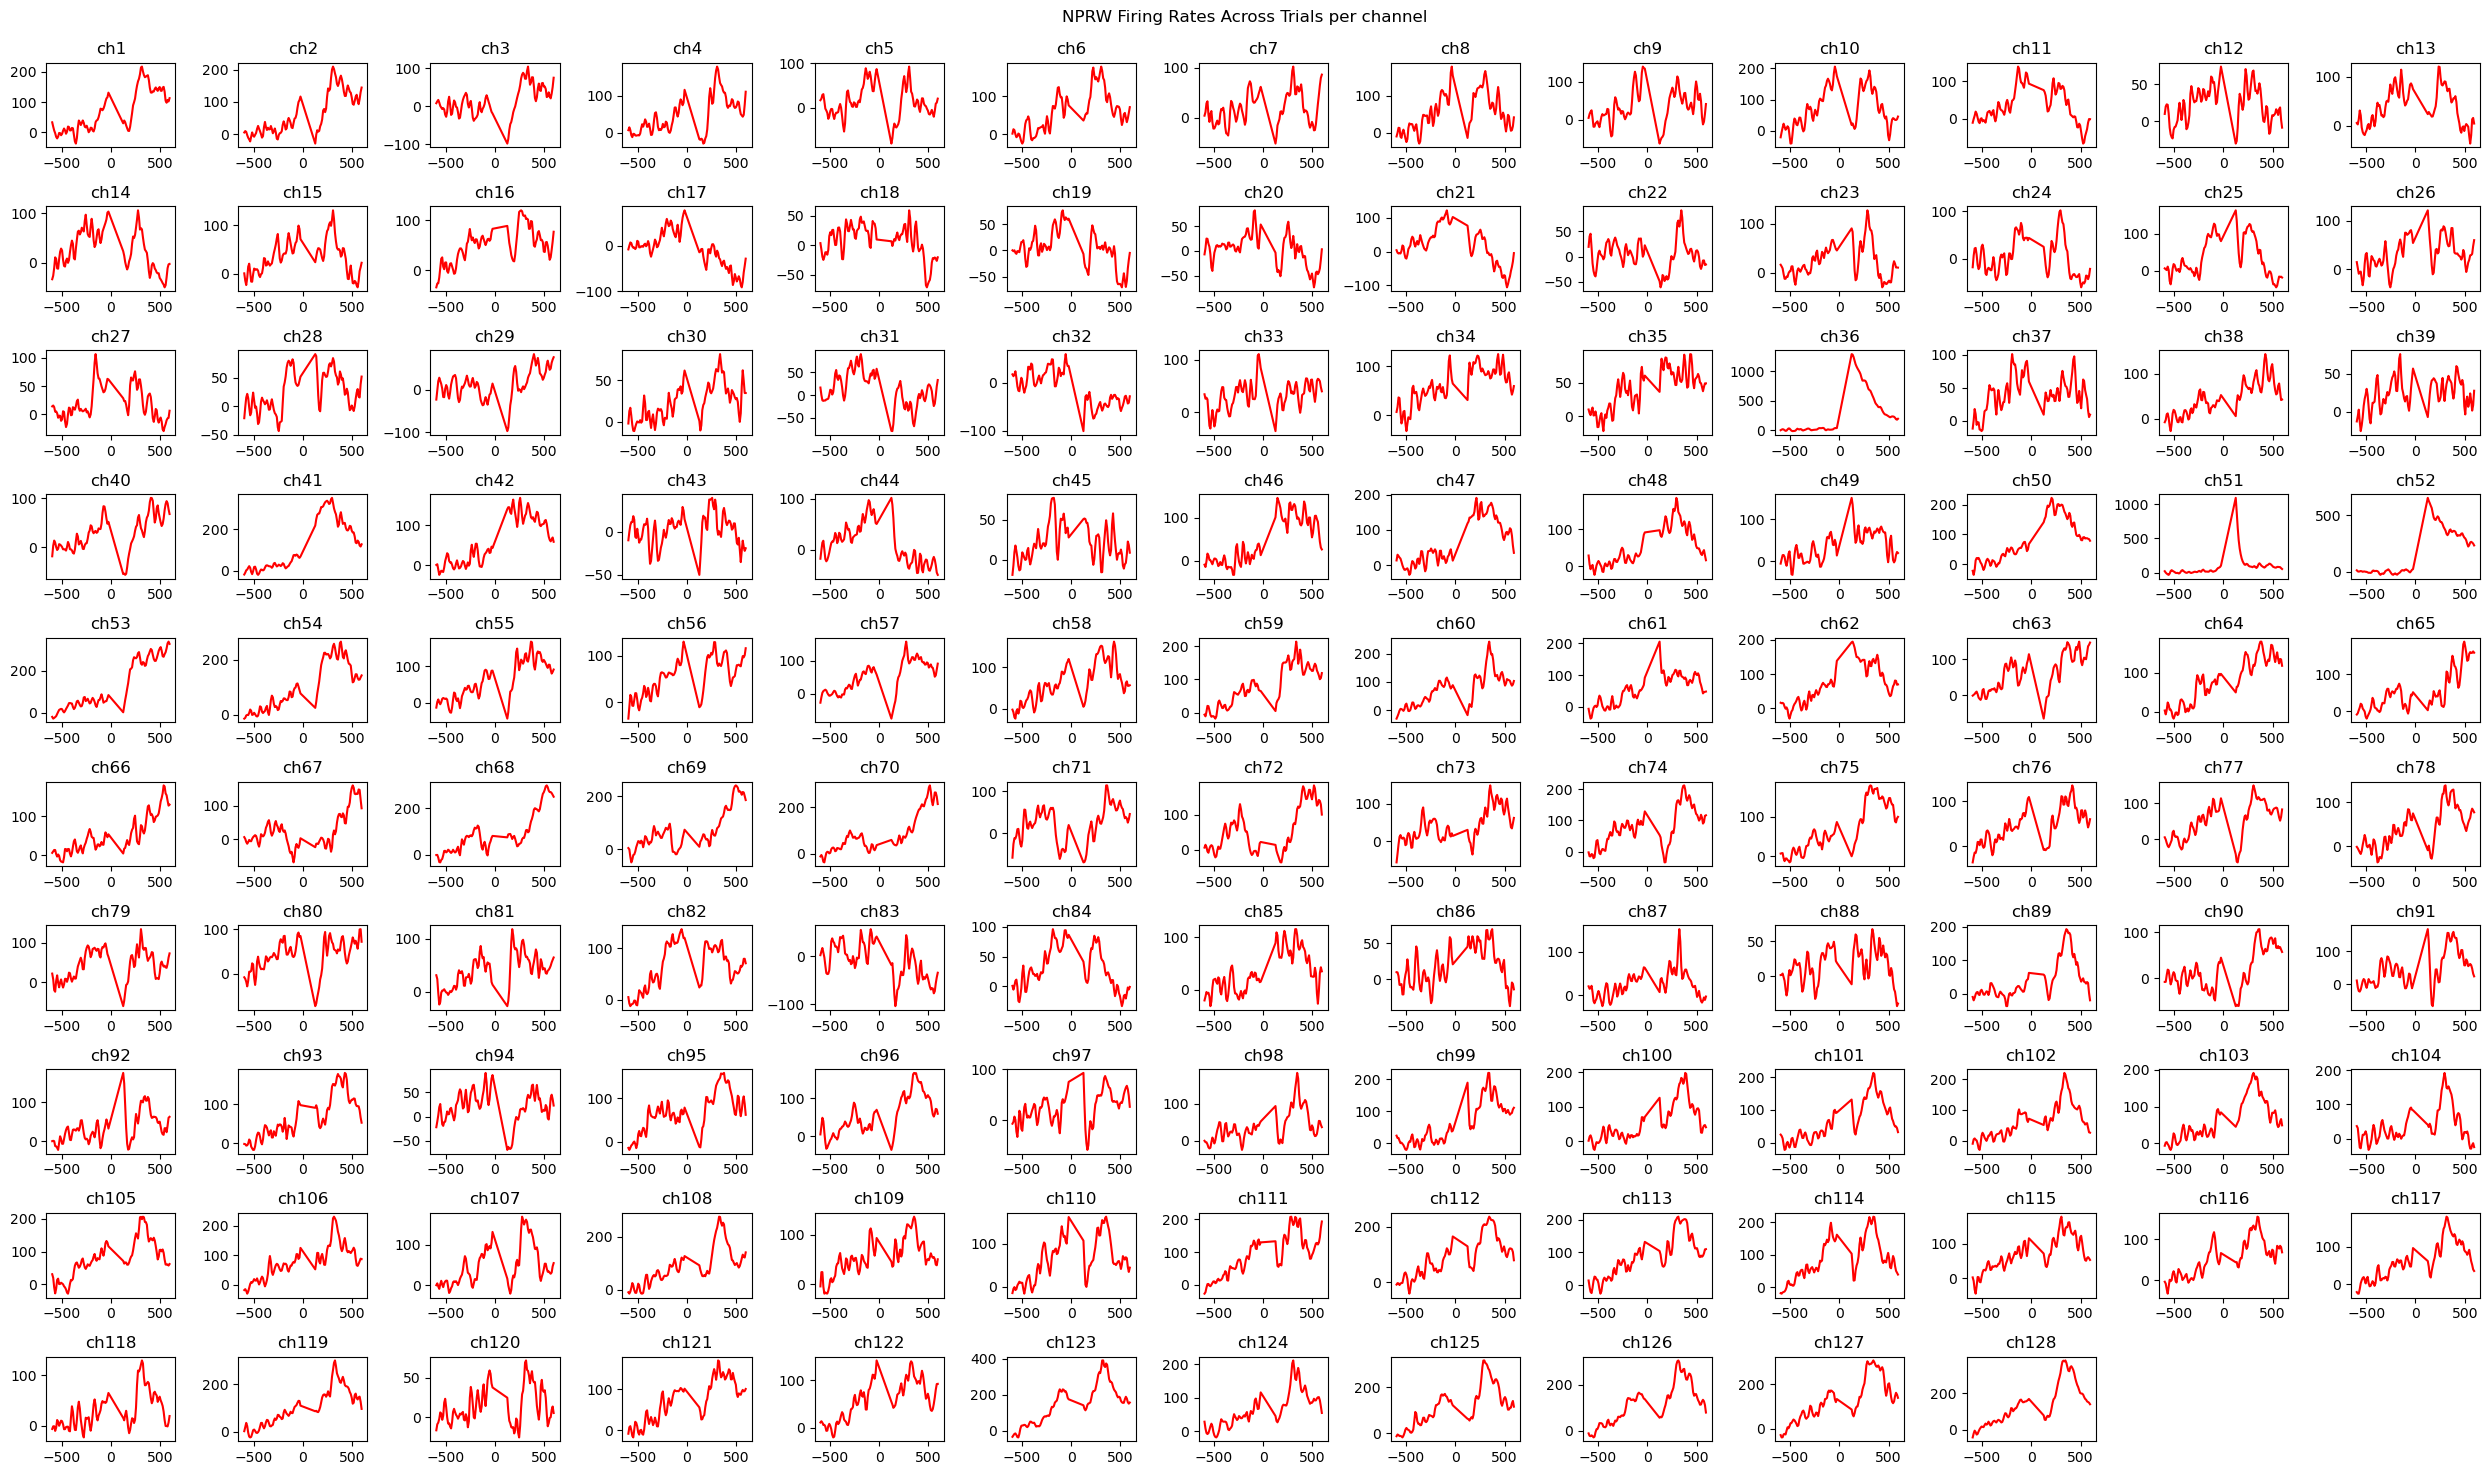

In [47]:
plt.figure(figsize=(25, 15))
for ch_select in range(128):
    plt.subplot(10,13, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(NPRW_rates_zeroed[:, ch_select, :], axis = 0).T,color="red")
    # plt.plot(NPRW_rel_t, NPRW_rates_zeroed[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.5)
    plt.title("ch" + str(ch_select + 1))
    
plt.suptitle("NPRW Firing Rates Across Trials per channel\n")
plt.tight_layout()

NPRW_rates_zeroed.shape

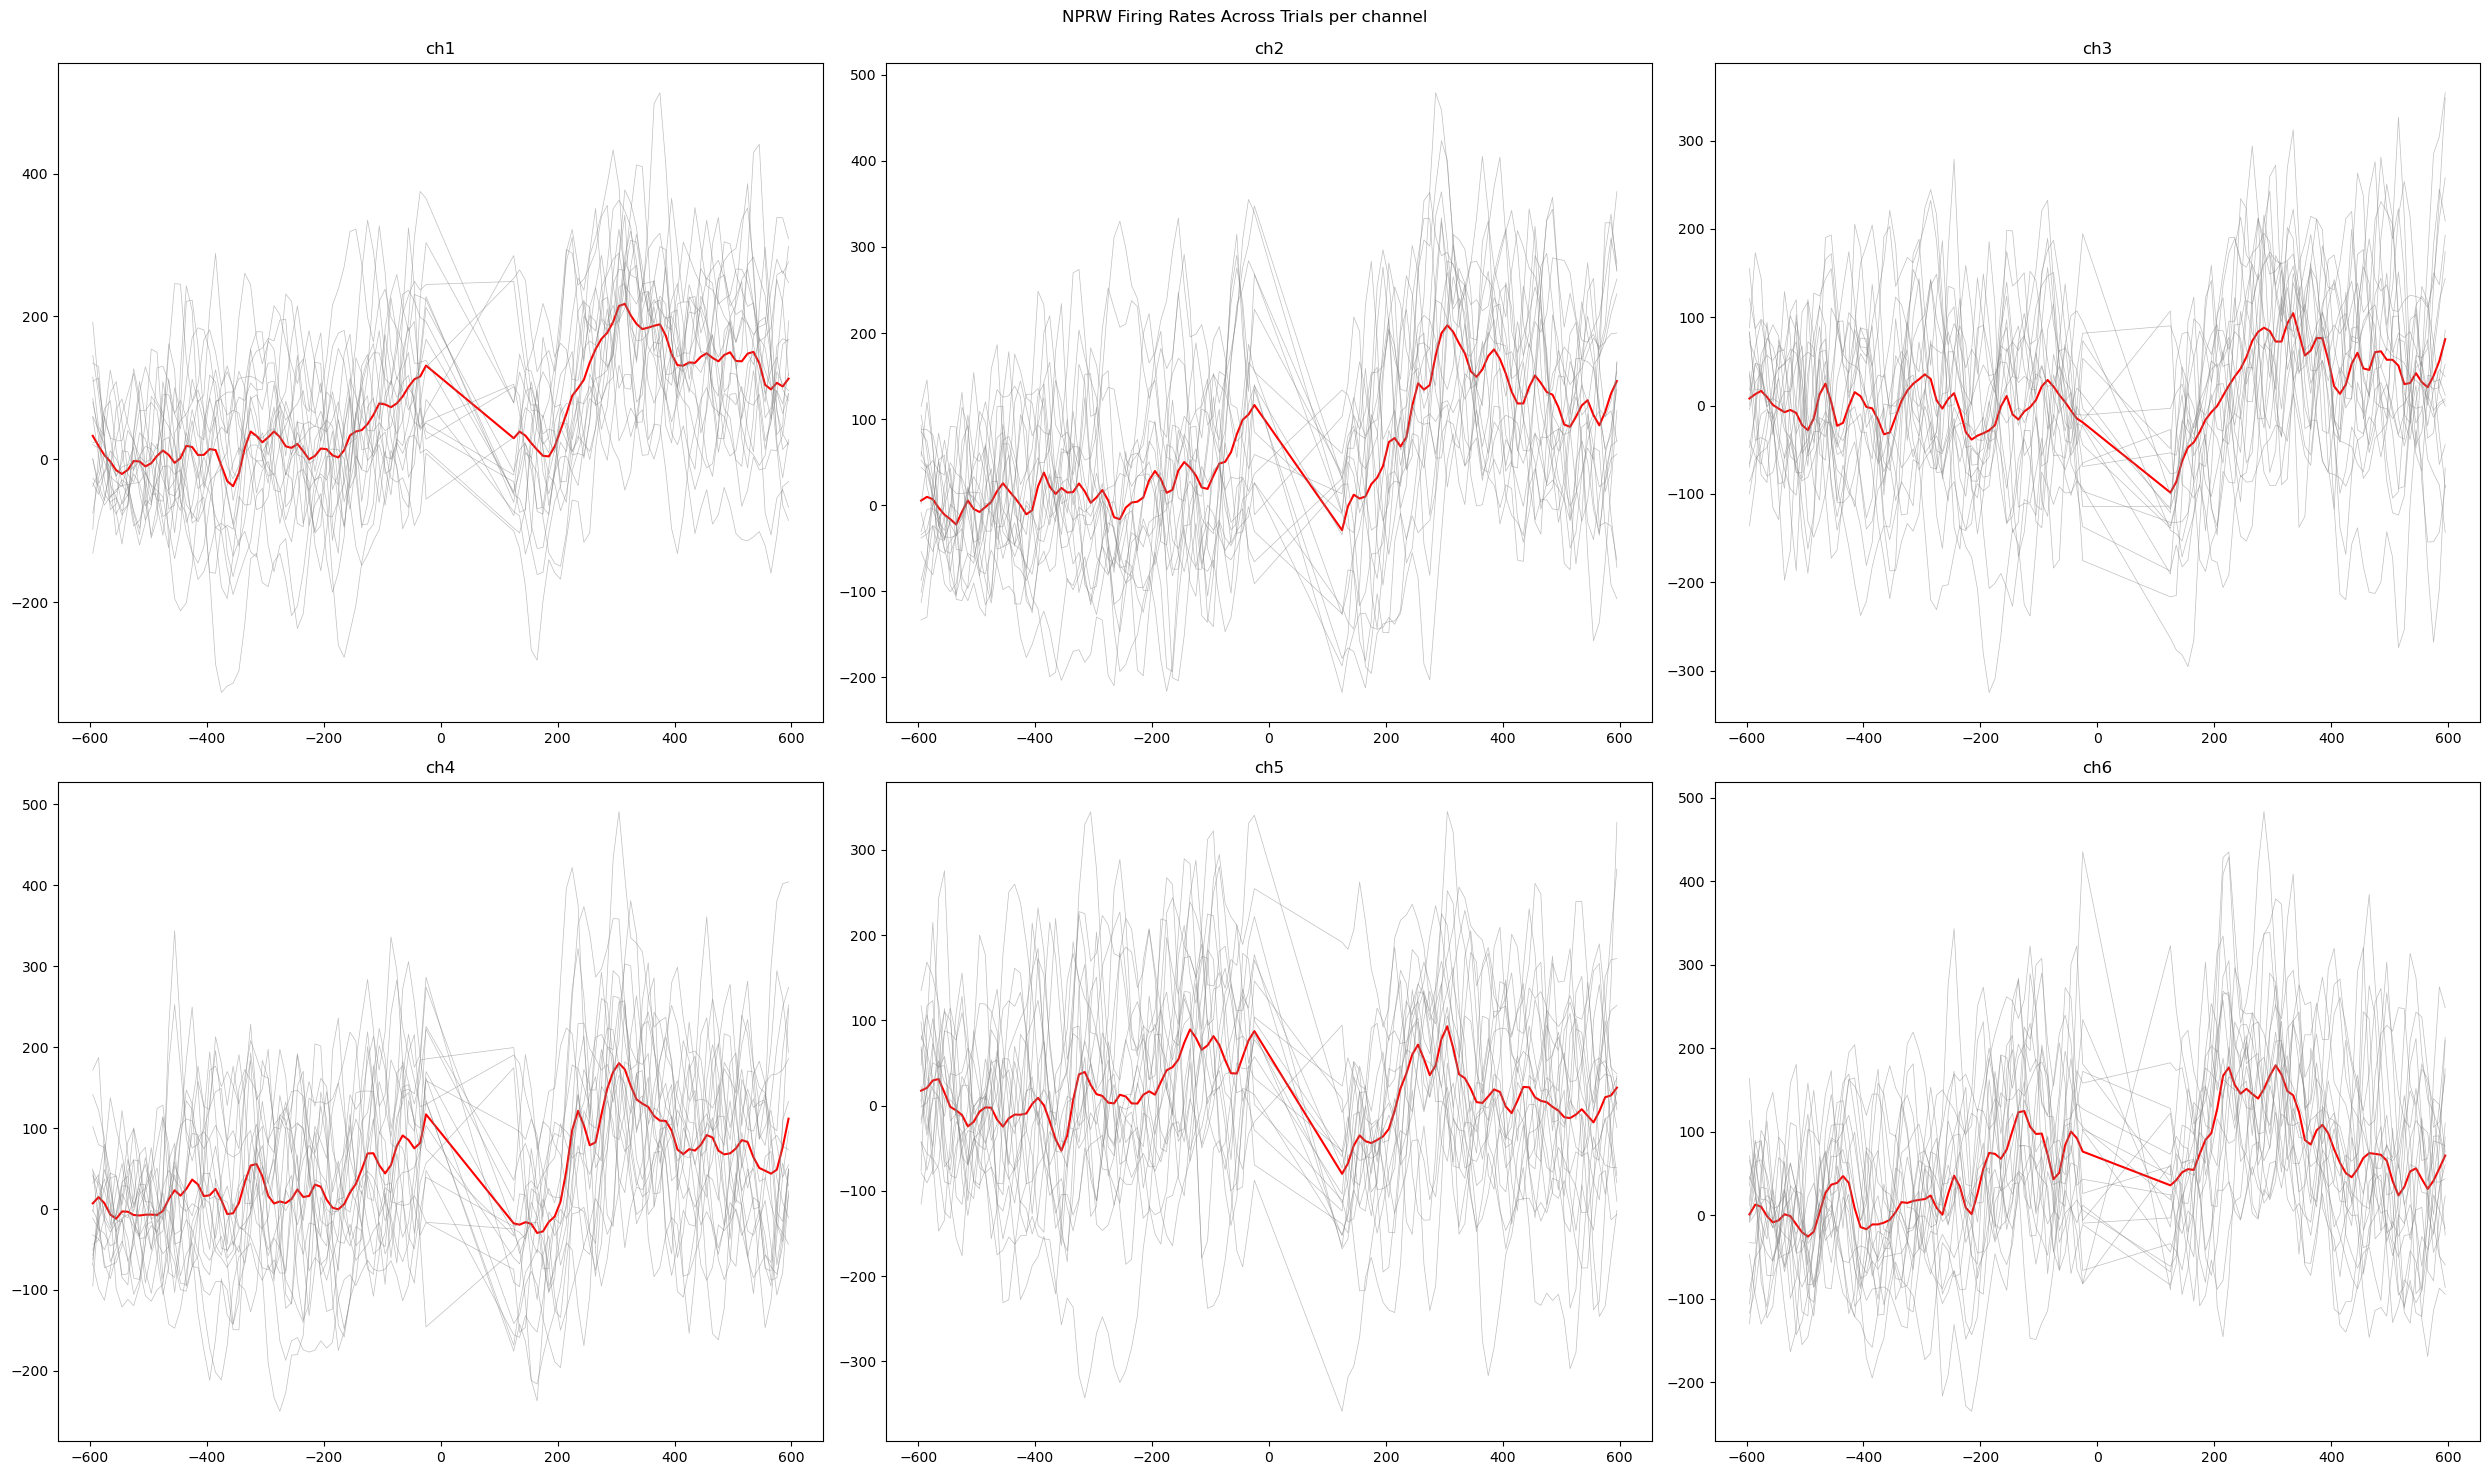

In [27]:
plt.figure(figsize=(25, 15))
for ch_select in range(6):
    plt.subplot(2, 3, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(NPRW_rates_zeroed[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, NPRW_rates_zeroed[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.5)
    plt.title("ch" + str(ch_select + 1))
    
plt.suptitle("NPRW Firing Rates Across Trials per channel\n")
plt.tight_layout()

In [96]:
from sklearn.decomposition import PCA

X = np.transpose(NPRW_rates_zeroed, axes=(0, 2, 1))  # (n_trials, n_bins, n_ch)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

num_PCs = 20

n_trials, n_bins, n_ch = X.shape
n_comp = min(num_PCs, n_bins, n_ch)

# Preallocate latents over time for each trial, and explained variance
pcs_all = np.zeros((n_trials, n_comp, n_bins), dtype=np.float32)
explained_var_all = np.zeros((n_trials, n_comp), dtype=np.float32)

for trial in range(n_trials):
    # PCA for each trial
    X_trial = X[trial, :, :]  # (n_bins, n_ch)
    total_var_trial = np.var(X_trial, axis=0).sum() # Total variance over time, but summed over channels
    if n_comp >= 1 and total_var_trial > 0.0:
        pca = PCA(n_components=n_comp) # For consistency
        pcs_trial = pca.fit_transform(X_trial)  # (n_bins, n_comp)
        pcs_all[trial] = pcs_trial.T.astype(np.float32)
        explained_var_all[trial] = np.nan_to_num(
            pca.explained_variance_ratio_, nan=0.0)
    else:
        pcs_all[trial] = 0.0
        explained_var_all[trial] = 0.0

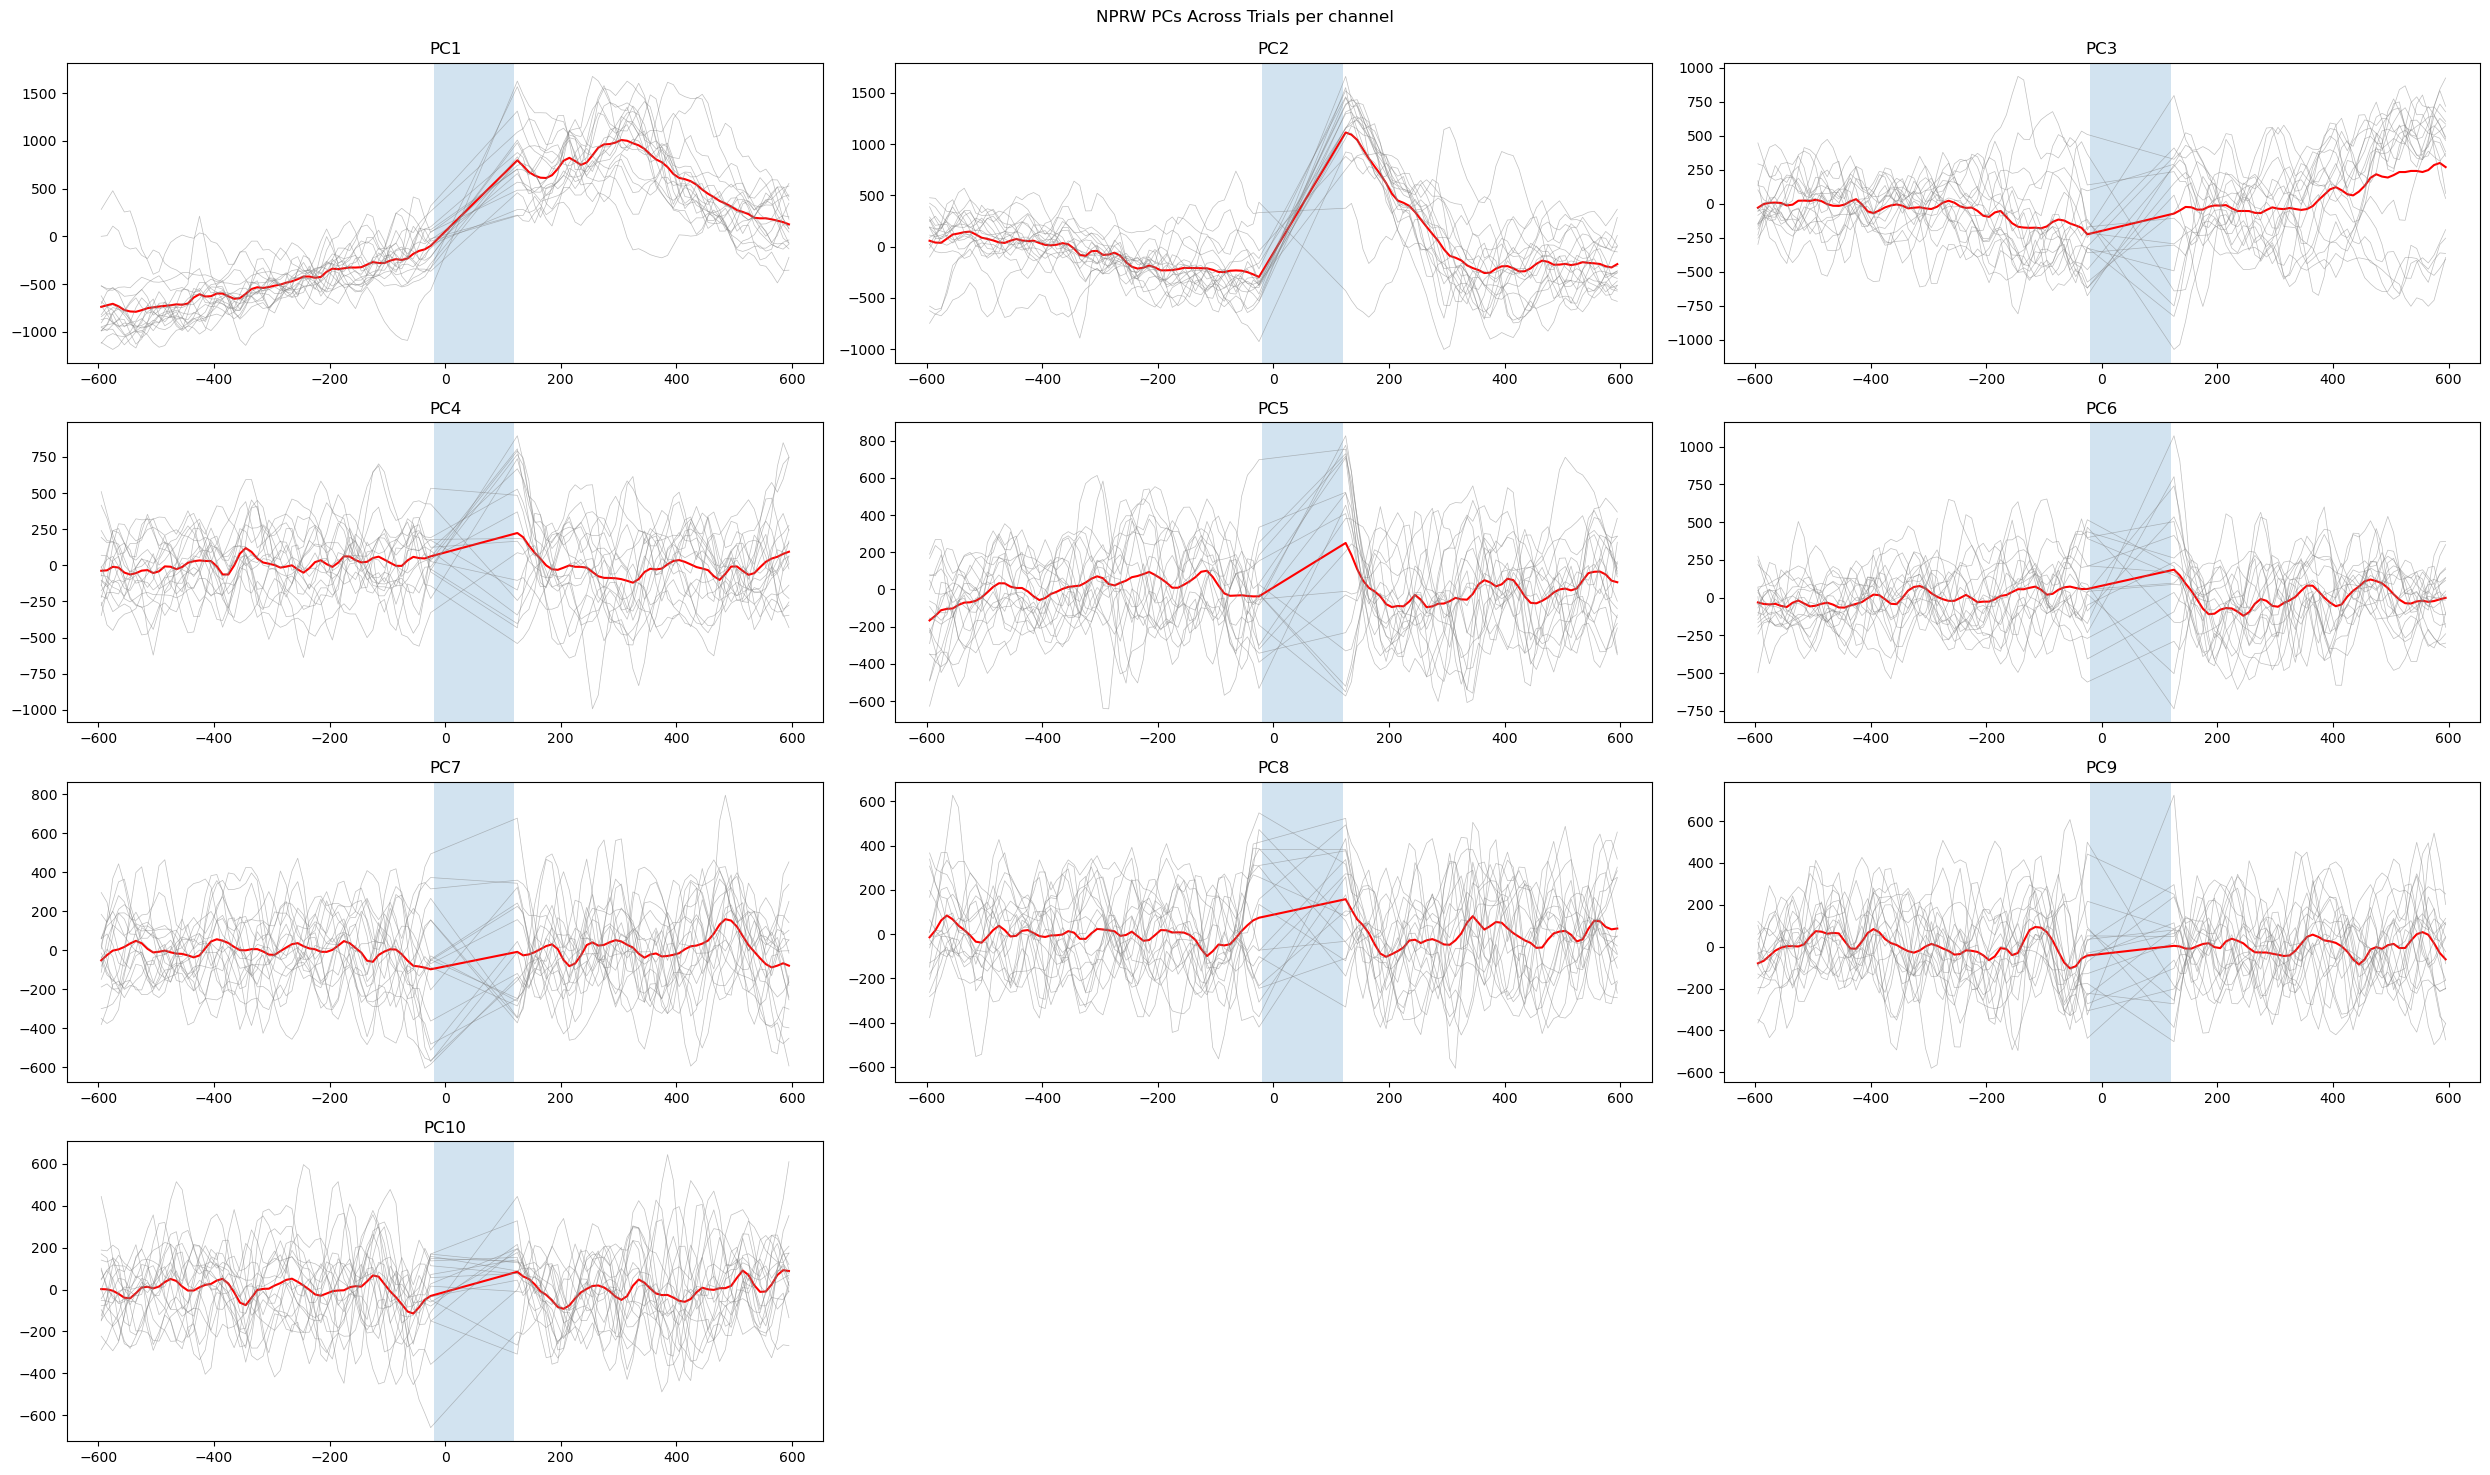

In [ ]:
plt.figure(figsize=(25, 15))
for ch_select in range(10):
    ax = plt.subplot(4, 3, ch_select+1)
    plt.plot(NPRW_rel_t, np.nanmean(pcs_all[:, ch_select, :], axis = 0).T,color="red")
    plt.plot(NPRW_rel_t, pcs_all[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.5)
    plt.title("PC" + str(ch_select + 1))
    ax.axvspan(-20, 120, alpha=0.2)
    
plt.suptitle("NPRW PCs over time\n")
plt.tight_layout()

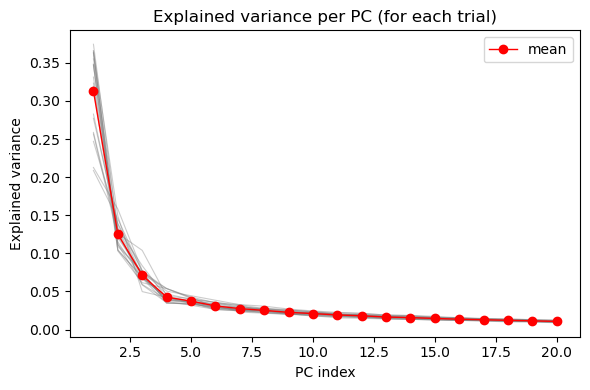

In [97]:
import numpy as np
import matplotlib.pyplot as plt

pc_idx = np.arange(1, num_PCs + 1)

plt.figure(figsize=(6, 4))
plt.plot(pc_idx, explained_var_all.T, color="gray", alpha=0.4, linewidth=0.8) # individual trials
plt.plot(pc_idx, explained_var_all.mean(axis=0), color="red", linewidth=1, marker="o", label="mean") # mean
plt.xlabel("PC index")
plt.ylabel("Explained variance")
plt.title("Explained variance per PC (for each trial)")
plt.legend()
plt.tight_layout()
plt.show()
